In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

### Загрузка и просмотр

In [2]:
df = pd.read_csv('titanic.csv')
print("Количество строк и столбцов:", df.shape)       # строки, столбцы
df.head(5)

Количество строк и столбцов: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# просмотр типов
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [4]:
df.isna().sum().sort_values(ascending=False)   # пропуски по столбцам

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [5]:
print("Дубликатов строк:", df.duplicated().sum())

Дубликатов строк: 0


Заполняем пропуски (просто и корректно)

Числовые столбцы — медианой.

Текст/категории — модой (самое частое значение).

In [6]:
# числовые → медиана
num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median(numeric_only=True))

# категориальные → мода (если вдруг мод нет, подставим 'Unknown')
obj_cols = df.select_dtypes(include=["object", "category"]).columns
for c in obj_cols:
    mode_vals = df[c].mode(dropna=True)
    fill_val = mode_vals.iloc[0] if len(mode_vals) else "Unknown"
    df[c] = df[c].fillna(fill_val)

# проверка
df.isna().sum().sort_values(ascending=False)


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

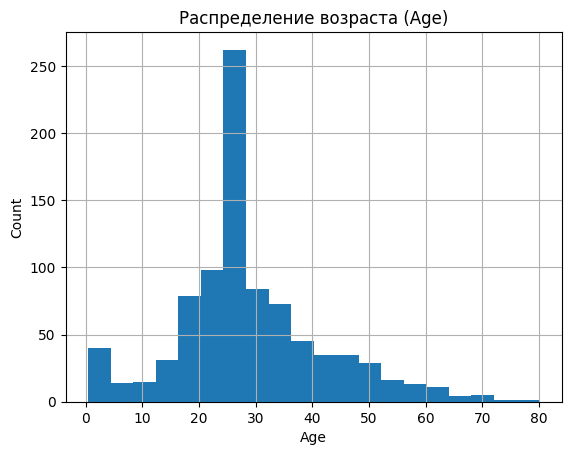

In [7]:
#Распределение возраста
if "Age" in df.columns:
    df["Age"].astype(float).hist(bins=20)
    plt.title("Распределение возраста (Age)")
    plt.xlabel("Age"); plt.ylabel("Count")
    plt.show()


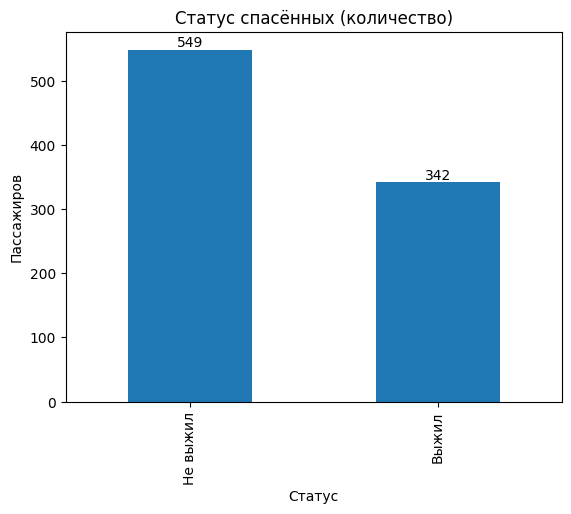

Доля выживших: 38% | не выживших: 62%


In [8]:
# количество выживших и не выживших
df["Survived"].value_counts(dropna=False)

# график с понятными подписями
ax = (df["Survived"]
      .value_counts()
      .sort_index()
      .rename(index={0: "Не выжил", 1: "Выжил"})
      .plot(kind="bar"))

plt.title("Статус спасённых (количество)")
plt.xlabel("Статус"); plt.ylabel("Пассажиров")

# подпишем числа над столбиками
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

# доли в процентах
share = df["Survived"].mean()
print(f"Доля выживших: {share:.0%} | не выживших: {1 - share:.0%}")


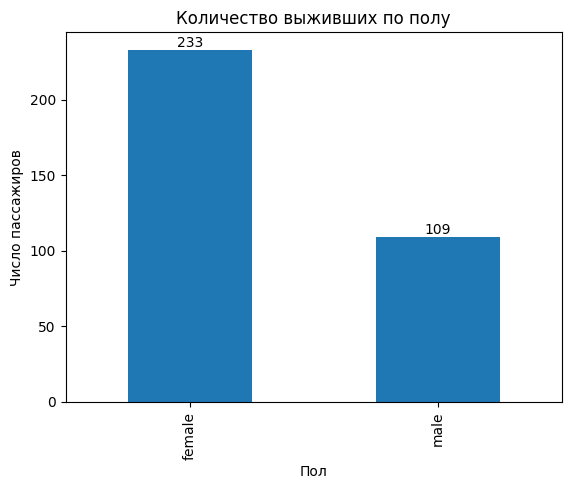

In [9]:
# гарантируем 0/1
df["Survived"] = df["Survived"].astype(int)

survived_by_sex = df.groupby("Sex")["Survived"].sum()  # сумма 1 = кол-во выживших
ax = survived_by_sex.plot(kind="bar")

plt.title("Количество выживших по полу")
plt.xlabel("Пол"); plt.ylabel("Число пассажиров")
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()


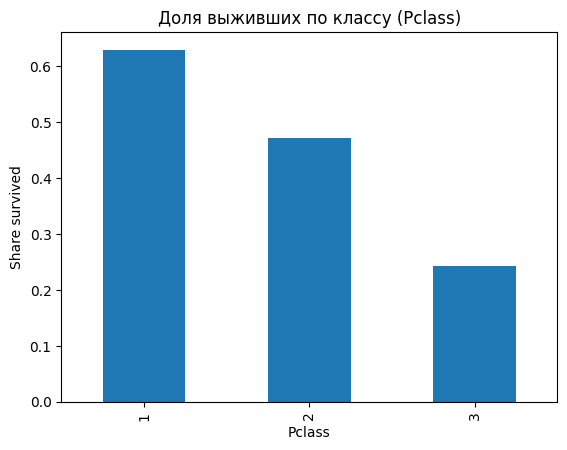

In [10]:
# Доля выживших по классу
if set(["Survived","Pclass"]).issubset(df.columns):
    (df.groupby("Pclass")["Survived"].mean()
      .sort_index()
      .plot(kind="bar"))
    plt.title("Доля выживших по классу (Pclass)")
    plt.xlabel("Pclass"); plt.ylabel("Share survived")
    plt.show()


In [11]:
# Сохраняем очищенный датасет
OUT_PATH = "titanic_cleaned.csv"
df.to_csv(OUT_PATH, index=False)
print("Сохранено в:", OUT_PATH, "| Размер:", df.shape)


Сохранено в: titanic_cleaned.csv | Размер: (891, 12)


## Количество выживших/не выживших по полу

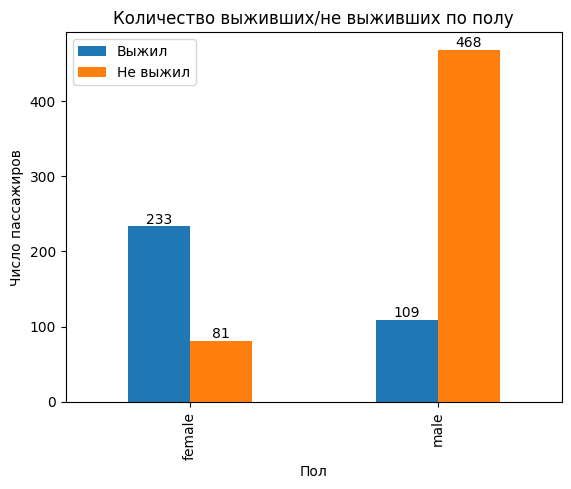

In [12]:
total_by_sex = df.groupby("Sex")["Survived"].size()
dead_by_sex = total_by_sex - survived_by_sex

counts = pd.DataFrame({
    "Выжил": survived_by_sex,
    "Не выжил": dead_by_sex
}).loc[sorted(df["Sex"].unique())]   # упорядочим по алфавиту

ax = counts.plot(kind="bar")
plt.title("Количество выживших/не выживших по полу")
plt.xlabel("Пол"); plt.ylabel("Число пассажиров")
for c in ax.containers:
    ax.bar_label(c, label_type="edge")
plt.show()


# Тепловая карта корреляций (числовые признаки)

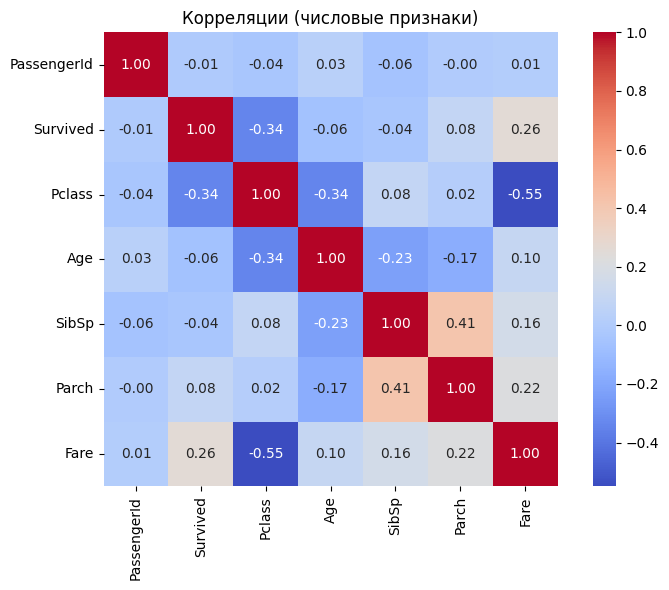

In [13]:
numeric = df.select_dtypes(include="number")
corr = numeric.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Корреляции (числовые признаки)")
plt.tight_layout()
plt.show()

### Минимальный пайплайн: кодируем категориальные, остальное пропускаем «как есть», учим неглубокое дерево и смотрим важности.

Accuracy: 0.793
              precision    recall  f1-score   support

           0       0.77      0.95      0.85       110
           1       0.86      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.82      0.75      0.76       179
weighted avg       0.81      0.79      0.78       179



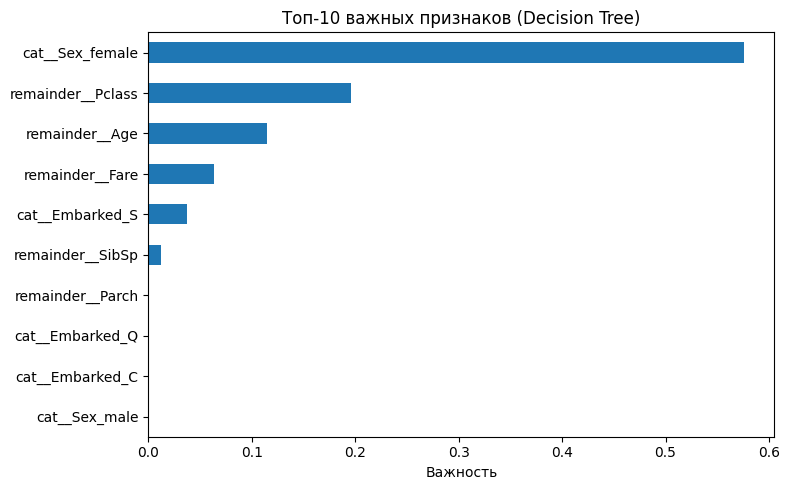

cat__Sex_female      0.576297
remainder__Pclass    0.195920
remainder__Age       0.114526
remainder__Fare      0.063141
cat__Embarked_S      0.037198
remainder__SibSp     0.012109
remainder__Parch     0.000809
cat__Sex_male        0.000000
cat__Embarked_C      0.000000
cat__Embarked_Q      0.000000
dtype: float64

In [14]:
# целевая переменная
y = df["Survived"].astype(int)

# базовый набор признаков (просто и понятно)
features = [
    "Sex", "Embarked",     # категориальные
    "Pclass", "Age", "Fare", "SibSp", "Parch"  # числовые
]
X = df[features].copy()

# раздельно перечислим типы столбцов
cat_cols = ["Sex", "Embarked"]
num_cols = ["Pclass", "Age", "Fare", "SibSp", "Parch"]

# препроцессор: one-hot для категорий, остальное как есть
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough"
)

# модель: неглубокое дерево, чтобы было читаемо
clf = DecisionTreeClassifier(max_depth=4, random_state=42)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", clf)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")
print(classification_report(y_test, y_pred))

# достанем имена признаков после OneHot
feature_names = pipe.named_steps["prep"].get_feature_names_out()
importances = pipe.named_steps["model"].feature_importances_

fi = (pd.Series(importances, index=feature_names)
        .sort_values(ascending=False)
        .head(10))

plt.figure(figsize=(8, 5))
fi.sort_values().plot(kind="barh")
plt.title("Топ-10 важных признаков (Decision Tree)")
plt.xlabel("Важность")
plt.tight_layout()
plt.show()

fi

Sex         0.576297
Pclass      0.195920
Age         0.114526
Fare        0.063141
Embarked    0.037198
SibSp       0.012109
Parch       0.000809
dtype: float64


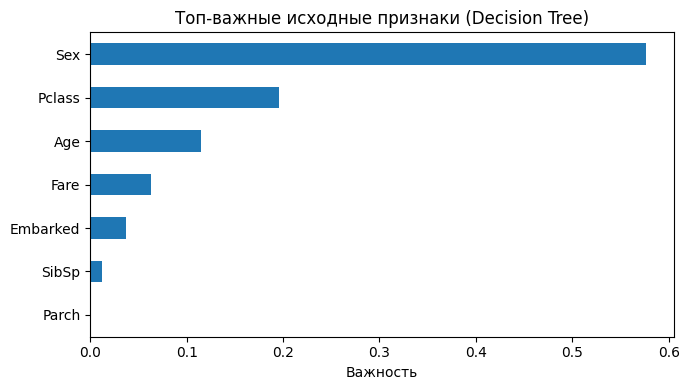

In [15]:
feature_names = pipe.named_steps["prep"].get_feature_names_out()
importances = pipe.named_steps["model"].feature_importances_

def orig_name(name: str) -> str:
    # 'cat__Sex_female' -> 'Sex'; 'remainder__Pclass' -> 'Pclass'; 'Fare' -> 'Fare'
    if "__" in name:
        right = name.split("__", 1)[1]     # 'Sex_female' или 'Pclass'
        return right.split("_", 1)[0]       # до первого '_' — исходное имя
    return name

agg = {}
for n, v in zip(feature_names, importances):
    agg[orig_name(n)] = agg.get(orig_name(n), 0.0) + v

fi_orig = pd.Series(agg).sort_values(ascending=False)
print(fi_orig.head(10))

# Красивый график
ax = fi_orig.head(10).sort_values().plot(kind="barh", figsize=(7,4))
ax.set_title("Топ-важные исходные признаки (Decision Tree)")
ax.set_xlabel("Важность")
plt.tight_layout()
plt.show()

Дисперсия (исходная): 62.5
Стандартное отклонение (рассчитанное вручную из дисперсии): 7.91

--- Сравнение результатов ---
NumPy std (ddof=0, 'population'): 7.07
NumPy std (ddof=1, 'sample'): 7.91
Pandas std (по умолчанию ddof=1): 7.91


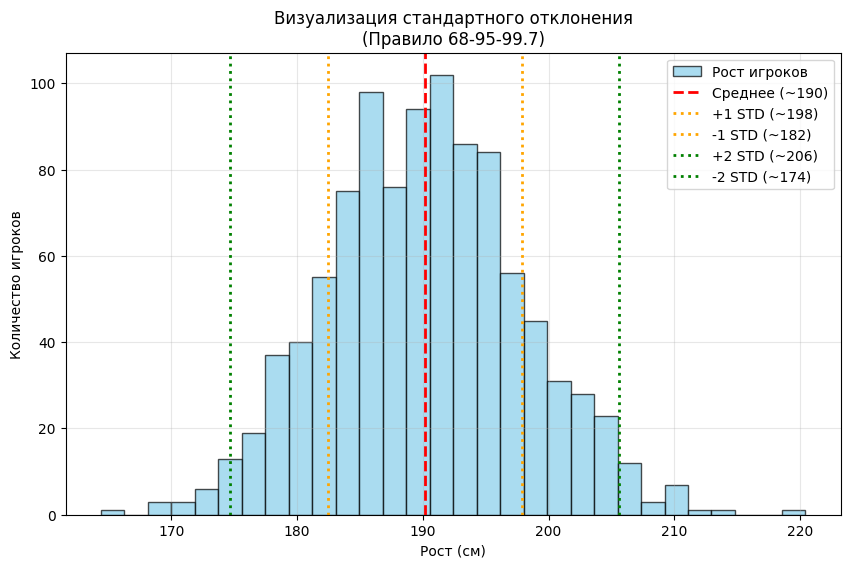

In [21]:
import numpy as np
import pandas as pd

# Наши данные
heights = [180, 185, 190, 195, 200]
heights_series = pd.Series(heights)

# РАСЧЁТ СТАНДАРТНОГО ОТКЛОНЕНИЯ

# 1. "Вручную", через дисперсию
variance_pandas = heights_series.var()  # Сначала считаем дисперсию (для выборки)
std_manual = np.sqrt(variance_pandas)   # Затем извлекаем корень

print(f"Дисперсия (исходная): {variance_pandas}")
print(f"Стандартное отклонение (рассчитанное вручную из дисперсии): {std_manual:.2f}")

# 2. Используем встроенные методы (гораздо проще!)
std_numpy = np.std(heights)                   # По умолчанию ddof=0 (для популяции)
std_numpy_sample = np.std(heights, ddof=1)    # Явно указываем ddof=1 (для выборки)

std_pandas = heights_series.std()             # Pandas по умолчанию использует ddof=1

print("\n--- Сравнение результатов ---")
print(f"NumPy std (ddof=0, 'population'): {std_numpy:.2f}")        # √50 ≈ 7.07
print(f"NumPy std (ddof=1, 'sample'): {std_numpy_sample:.2f}")     # √62.5 ≈ 7.91
print(f"Pandas std (по умолчанию ddof=1): {std_pandas:.2f}")       # √62.5 ≈ 7.91

# 3. ВИЗУАЛИЗАЦИЯ для понимания (самое главное!)
import matplotlib.pyplot as plt

# Создадим данные, похожие на нормальное распределение
np.random.seed(42) # для воспроизводимости результата
data = np.random.normal(190, 7.9, 1000) # среднее=190, std=7.9, 1000 точек

# Нарисуем гистограмму
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, alpha=0.7, color='skyblue', edgecolor='black', label='Рост игроков')
plt.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее (~190)')

# Покажем ±1 и ±2 стандартных отклонения
one_std = data.std()
two_std = data.std() * 2

plt.axvline(data.mean() + one_std, color='orange', linestyle=':', linewidth=2, label=f'+1 STD (~{190+7.9:.0f})')
plt.axvline(data.mean() - one_std, color='orange', linestyle=':', linewidth=2, label=f'-1 STD (~{190-7.9:.0f})')
plt.axvline(data.mean() + two_std, color='green', linestyle=':', linewidth=2, label=f'+2 STD (~{190+15.8:.0f})')
plt.axvline(data.mean() - two_std, color='green', linestyle=':', linewidth=2, label=f'-2 STD (~{190-15.8:.0f})')

plt.title('Визуализация стандартного отклонения\n(Правило 68-95-99.7)')
plt.xlabel('Рост (см)')
plt.ylabel('Количество игроков')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

=== ДЕСКРИПТИВНАЯ СТАТИСТИКА ===
            count        mean       std        min         25%         50%  \
fertilizer                                                                   
A            30.0   99.059266  4.500032  90.433599   97.044746   98.829274   
B            30.0  104.394188  4.655511  95.201649  101.454432  104.677136   
C            30.0  110.064424  4.959915  96.901274  107.429290  110.128053   

                   75%         max  
fertilizer                          
A           101.801677  107.896064  
B           107.723309  114.261391  
C           113.688556  117.823218  


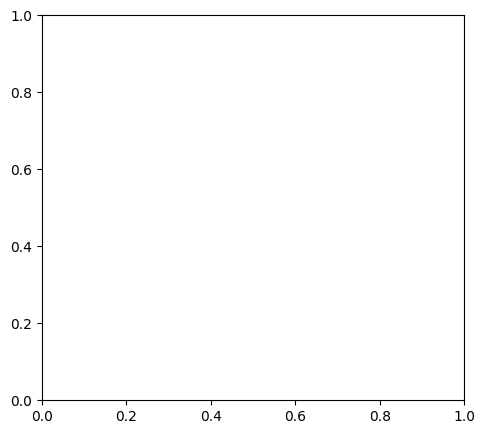

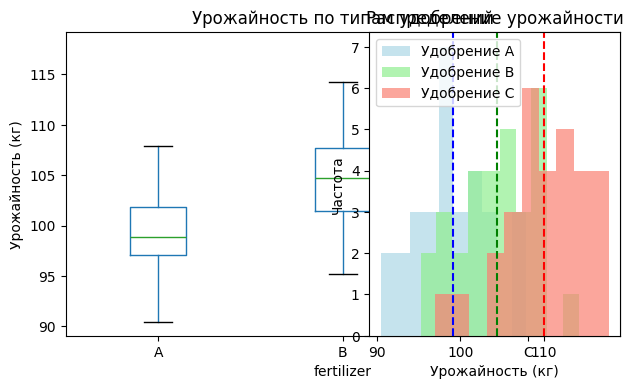

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Генерируем данные по урожайности для трёх удобрений (в кг с гектара)
np.random.seed(42)  # для воспроизводимости

# Удобрение A (средняя урожайность ~100)
fert_a = np.random.normal(100, 5, 30)  # 30 полей, среднее=100, std=5
# Удобрение B (средняя урожайность ~105)
fert_b = np.random.normal(105, 5, 30)
# Удобрение C (средняя урожайность ~110)
fert_c = np.random.normal(110, 5, 30)

# Создаём DataFrame - так удобнее работать с разными группами
df = pd.DataFrame({
    'yield': np.concatenate([fert_a, fert_b, fert_c]),
    'fertilizer': ['A'] * 30 + ['B'] * 30 + ['C'] * 30
})

print("=== ДЕСКРИПТИВНАЯ СТАТИСТИКА ===")
print(df.groupby('fertilizer')['yield'].describe())

# ВИЗУАЛИЗАЦИЯ данных
plt.figure(figsize=(12, 5))

# Box Plot - идеален для сравнения групп
plt.subplot(1, 2, 1)
df.boxplot(column='yield', by='fertilizer', grid=False)
plt.title('Урожайность по типам удобрений')
plt.suptitle('') # убираем автоматический заголовок
plt.ylabel('Урожайность (кг)')

# Гистограммы для каждой группы
plt.subplot(1, 2, 2)
for fert, color in zip(['A', 'B', 'C'], ['lightblue', 'lightgreen', 'salmon']):
    plt.hist(df[df['fertilizer'] == fert]['yield'], 
             alpha=0.7, label=f'Удобрение {fert}', color=color, bins=10)
plt.axvline(df[df['fertilizer']=='A']['yield'].mean(), color='blue', linestyle='--')
plt.axvline(df[df['fertilizer']=='B']['yield'].mean(), color='green', linestyle='--')
plt.axvline(df[df['fertilizer']=='C']['yield'].mean(), color='red', linestyle='--')
plt.xlabel('Урожайность (кг)')
plt.ylabel('Частота')
plt.legend()
plt.title('Распределение урожайности')

plt.tight_layout()
plt.show()

In [23]:
# ПРОВЕДЕНИЕ ANOVA ТЕСТА

# Разделяем данные по группам
group_a = df[df['fertilizer'] == 'A']['yield']
group_b = df[df['fertilizer'] == 'B']['yield']
group_c = df[df['fertilizer'] == 'C']['yield']

# Проводим однофакторный ANOVA (one-way ANOVA)
f_stat, p_value = stats.f_oneway(group_a, group_b, group_c)

print("\n=== РЕЗУЛЬТАТЫ ANOVA ТЕСТА ===")
print(f"F-статистика: {f_stat:.4f}")
print(f"P-value: {p_value:.10f}")

# ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТА
alpha = 0.05  # стандартный уровень значимости (5%)

print("\n=== ИНТЕРПРЕТАЦИЯ ===")
if p_value < alpha:
    print(f"✅ P-value ({p_value:.4f}) < {alpha}.")
    print("ОТКЛОНЯЕМ нулевую гипотезу.")
    print("ВЫВОД: Существует статистически значимая разница в средней урожайности между как минимум двумя удобрениями.")
else:
    print(f"❌ P-value ({p_value:.4f}) >= {alpha}.")
    print("НЕ ОТКЛОНЯЕМ нулевую гипотезу.")
    print("ВЫВОД: Нет убедительных доказательств того, что удобрения влияют на урожайность.")

# ДОПОЛНИТЕЛЬНО: Посчитаем дисперсию внутри и между группами для наглядности
overall_mean = df['yield'].mean()

# Дисперсия МЕЖДУ группами (Between-group variance)
ss_between = sum([len(group) * (group.mean() - overall_mean)**2 
                 for group in [group_a, group_b, group_c]])
df_between = 2  # degrees of freedom (количество групп - 1)

# Дисперсия ВНУТРИ групп (Within-group variance)
ss_within = sum([sum((group - group.mean())**2) 
                for group in [group_a, group_b, group_c]])
df_within = len(df) - 3  # (общее кол-во наблюдений - количество групп)

# Средние квадраты (Mean Squares)
ms_between = ss_between / df_between
ms_within = ss_within / df_within

# F-статистика (та же, что рассчитала функция)
f_stat_manual = ms_between / ms_within

print(f"\n--- Ручной расчет для понимания ---")
print(f"Дисперсия МЕЖДУ группами: {ms_between:.2f}")
print(f"Дисперсия ВНУТРИ групп: {ms_within:.2f}")
print(f"F-статистика (расчетная): {f_stat_manual:.4f}")


=== РЕЗУЛЬТАТЫ ANOVA ТЕСТА ===
F-статистика: 40.9756
P-value: 0.0000000000

=== ИНТЕРПРЕТАЦИЯ ===
✅ P-value (0.0000) < 0.05.
ОТКЛОНЯЕМ нулевую гипотезу.
ВЫВОД: Существует статистически значимая разница в средней урожайности между как минимум двумя удобрениями.

--- Ручной расчет для понимания ---
Дисперсия МЕЖДУ группами: 908.63
Дисперсия ВНУТРИ групп: 22.17
F-статистика (расчетная): 40.9756



=== POST-HOC TEST (Tukey HSD) ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     A      B   5.3349 0.0001 2.4357  8.2341   True
     A      C  11.0052    0.0  8.106 13.9044   True
     B      C   5.6702    0.0  2.771  8.5694   True
---------------------------------------------------


<Figure size 800x500 with 0 Axes>

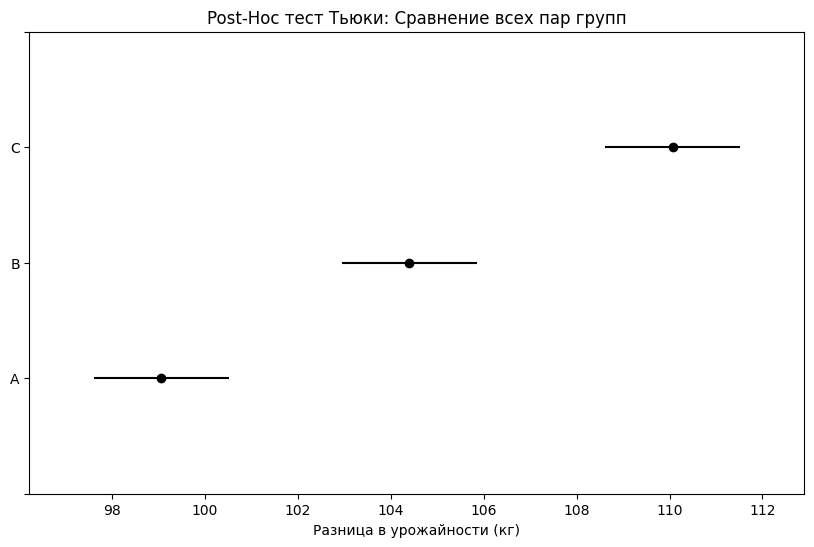

In [25]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Проводим Post-Hoc тест Тьюки
tukey_result = pairwise_tukeyhsd(endog=df['yield'], groups=df['fertilizer'], alpha=0.05)

print("\n=== POST-HOC TEST (Tukey HSD) ===")
print(tukey_result)

# Визуализируем доверительные интервалы различий
plt.figure(figsize=(8, 5))
tukey_result.plot_simultaneous()
plt.title('Post-Hoc тест Тьюки: Сравнение всех пар групп')
plt.xlabel('Разница в урожайности (кг)')
plt.show()

In [2]:
import numpy as np
import pandas as pd

# Наши данные
heights = [180, 185, 190, 195, 200]

# Создаем Series из Pandas (удобная структура для анализа)
heights_series = pd.Series(heights)

# РАСЧЁТ ДИСПЕРСИИ

# 1. "Вручную", по шагам (чтобы понять суть)
mean_height = heights_series.mean() # Находим среднее
deviations = heights_series - mean_height # Находим отклонения (шаг 1)
squared_deviations = deviations ** 2 # Возводим в квадрат (шаг 2)
variance_manual = squared_deviations.mean() # Находим среднее (шаг 3)

print(f"Средний рост: {mean_height}")
print(f"Отклонения: {list(deviations)}")
print(f"Квадраты отклонений: {list(squared_deviations)}")
print(f"Дисперсия (рассчитанная вручную): {variance_manual}")

# 2. Используем встроенные методы
# Дисперсия для генеральной совокупности (ddof=0)
variance_numpy = np.var(heights)
# Дисперсия для выборки (ddof=1) - используется по умолчанию в большинстве случаев
variance_numpy_sample = np.var(heights, ddof=1)

variance_pandas = heights_series.var() # Pandas по умолчанию использует ddof=1

print("\n--- Сравнение результатов ---")
print(f"NumPy var (ddof=0, 'population'): {variance_numpy}") # 50.0
print(f"NumPy var (ddof=1, 'sample'): {variance_numpy_sample}") # 62.5
print(f"Pandas var (по умолчанию ddof=1): {variance_pandas}") # 62.5

Средний рост: 190.0
Отклонения: [-10.0, -5.0, 0.0, 5.0, 10.0]
Квадраты отклонений: [100.0, 25.0, 0.0, 25.0, 100.0]
Дисперсия (рассчитанная вручную): 50.0

--- Сравнение результатов ---
NumPy var (ddof=0, 'population'): 50.0
NumPy var (ddof=1, 'sample'): 62.5
Pandas var (по умолчанию ddof=1): 62.5


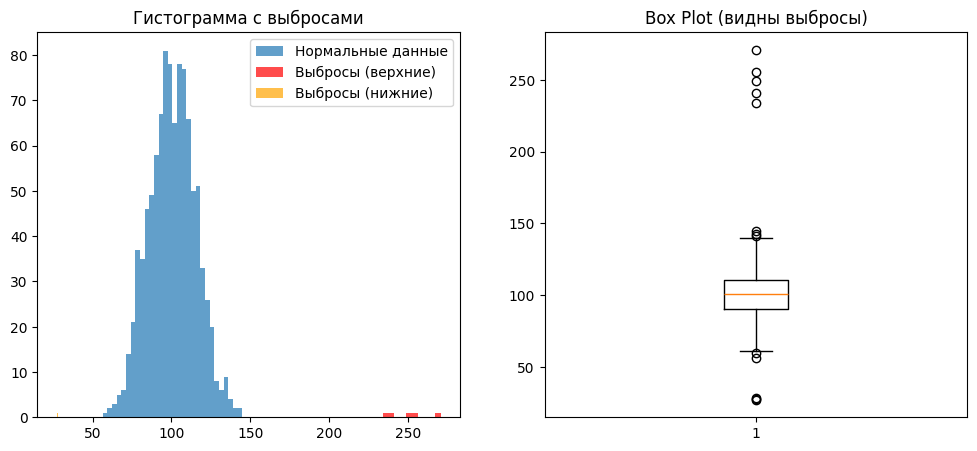

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Нормальные данные с парой выбросов
normal_data = np.random.normal(100, 15, 1000)  # основная масса данных
outliers_high = np.random.normal(250, 10, 5)   # выбросы сверху
outliers_low = np.random.normal(30, 5, 3)      # выбросы снизу

data_with_outliers = np.concatenate([normal_data, outliers_high, outliers_low])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(normal_data, alpha=0.7, bins=30, label='Нормальные данные')
plt.hist(outliers_high, alpha=0.7, bins=10, color='red', label='Выбросы (верхние)')
plt.hist(outliers_low, alpha=0.7, bins=10, color='orange', label='Выбросы (нижние)')
plt.title('Гистограмма с выбросами')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(data_with_outliers)
plt.title('Box Plot (видны выбросы)')
plt.show()

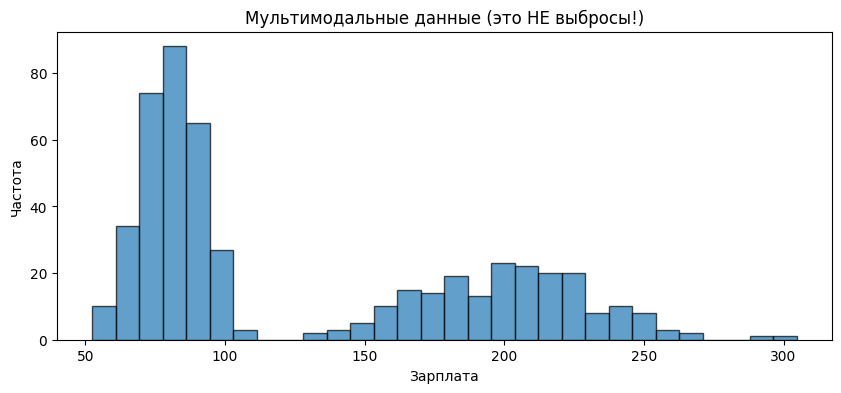

In [4]:
# Данные с двумя модами - это НЕ выбросы!
salary_junior = np.random.normal(80, 10, 300)   # мода 1: junior
salary_senior = np.random.normal(200, 30, 200)  # мода 2: senior

multimodal_data = np.concatenate([salary_junior, salary_senior])

plt.figure(figsize=(10, 4))
plt.hist(multimodal_data, bins=30, alpha=0.7, edgecolor='black')
plt.title('Мультимодальные данные (это НЕ выбросы!)')
plt.xlabel('Зарплата')
plt.ylabel('Частота')
plt.show()